In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import soundfile as sf
import matplotlib.pyplot as plt


## Vizualize f0 contours

In [5]:
ref_file = Path("01_GabrielMoreno_YoNoTeHeDaoMotivos")

gt_folder = Path("../data/cante2midi_groundTruth")
f0auto_folder = Path("../data/cante2midi_f0")
bark_bands_folder = Path("../data/cante2midi_bakbands")
audio_folder = Path("../data/cante2midiaudio")
spec_folder = Path("../data/cante2midi_spectrum")
PESTO_f0_folder = Path("../f0est/f0Contour_voiceDemucs_PESTO")

wav, sr = sf.read(str(audio_folder/ref_file.with_suffix(".wav")))
print(f"Audio loaded ! Samples = {len(wav)}    Dur = {(len(wav)/sr):.2f} sec. (sf={sr})")

f0_contour = pd.read_csv(f0auto_folder/ref_file.with_suffix(".f0.csv"), names = ['time', 'f0'])
bark_bands = pd.read_csv(bark_bands_folder/ref_file.with_suffix(".barkbands.csv"),
                         sep=" ",
                         names= [0.0, 50.0, 100.0, 150.0, 200.0, 300.0, 400.0, 510.0, 630.0, 770.0, 920.0, 1080.0, 1270.0, 1480.0, 1720.0, 2000.0, 2320.0, 2700.0, 3150.0, 3700.0, 4400.0, 5300.0, 6400.0, 7700.0, 9500.0, 12000.0, 15500.0, 20500.0, 27000.0])
spec = pd.read_csv(spec_folder/ref_file.with_suffix(".spectrum.csv"),
                   sep=" ",
                   header =None)

pesto_pred = pd.read_csv(PESTO_f0_folder/ref_file.with_suffix(".f0.csv"))

Audio loaded ! Samples = 10973952    Dur = 248.84 sec. (sf=44100)


In [6]:
print(len(f0_contour))
print(len(pesto_pred))

85746
85735


In [7]:
# split columns
time = spec.iloc[:,0]
magnitudes = spec.iloc[:,1:514]   # shape: (frames, bins)

print(magnitudes.shape)


sample_rate = 44100
fft_size = 1024

bins = magnitudes.shape[1]

freqs = np.arange(bins) * sample_rate / fft_size
magnitudes_db = 20 * np.log10(magnitudes + 1e-10)

(21435, 513)


In [8]:
# remove unvoiced frames
f0_plot = f0_contour.copy()
f0_plot.loc[f0_plot.f0 <= 0, "f0"] = np.nan
f0PESTO_plot = pesto_pred.copy()
f0PESTO_plot.loc[f0PESTO_plot.f0_hz <= 0, "f0_hz"] = np.nan

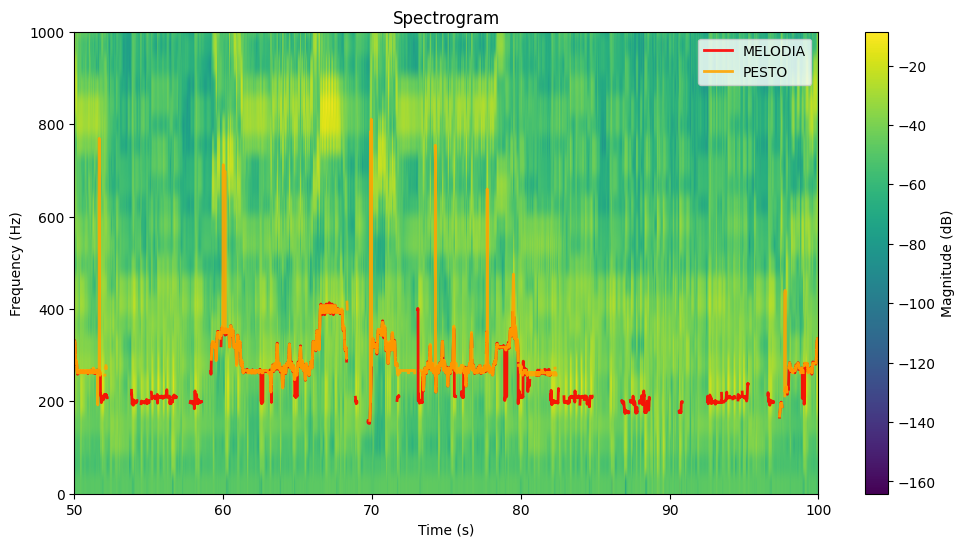

In [9]:
plt.figure(figsize=(12,6))

max_freq = 5000
max_bin = int(max_freq * fft_size / sample_rate)

plt.imshow(
    magnitudes_db.iloc[:,:max_bin].T,
    aspect='auto',
    origin='lower',
    extent=[time.min(), time.max(), freqs.min(), max_freq]
)
plt.plot(f0_plot.time, f0_plot.f0, color="red", linewidth=2, label="MELODIA", alpha=0.9)
plt.plot(f0PESTO_plot.time_sec, f0PESTO_plot.f0_hz, color="orange", linewidth=2, label="PESTO", alpha=0.9)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram")
plt.colorbar(label="Magnitude (dB)")
plt.ylim(0, 1000)
plt.xlim(50, 100)
plt.legend()

plt.show()

## `note_transcription.py` function overview

This section is a compact walkthrough of the key functions in `noteTranscription/note_transcription.py`:

1. Helpers (`hz_to_cents`, `voiced_segments`, `check_and_align_features`)
2. Segmentation onset detectors
3. Pitch-labelling functions
4. End-to-end `transcribe_notes` pipeline

All examples below use synthetic data so they can run independently.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from note_transcription import (
    hz_to_cents,
    voiced_segments,
    check_and_align_features,
    detect_onsets_local_maxima,
    detect_onsets_gaussian_derivative,
    detect_onsets_volume_dip,
    detect_onsets_pitch_dip,
    merge_and_deduplicate,
    segment_contour,
    estimate_tuning_deviation,
    compute_global_pitch_class_probability,
    compute_local_pitch_probability,
    assign_pitch_label,
    transcribe_notes,
)

fs = 44100
target_hop = 128
hop_s = target_hop / fs
print('Imports ready.')

Imports ready.


In [3]:
# --- Synthetic data for examples ---
rng = np.random.default_rng(0)
duration_s = 8.0
n_frames = int(duration_s / hop_s)

# f0 at 128-hop with voiced/unvoiced regions
f0_128 = np.zeros(n_frames)
note_regions = [
    (0.5, 2.0, 261.63),
    (2.3, 4.0, 293.66),
    (4.4, 6.2, 329.63),
]

for t0, t1, f in note_regions:
    s = int(t0 / hop_s)
    e = int(t1 / hop_s)
    t = np.arange(e - s) * hop_s
    vibrato = 1 + 0.004 * np.sin(2 * np.pi * 5 * t)
    f0_128[s:e] = f * vibrato + rng.normal(0, 0.3, e - s)

# lowlevel + spectrum at 512-hop (to demonstrate check_and_align_features)
ll_hop = 512
sp_hop = 512
ll_hop_s = ll_hop / fs
n_512 = int(duration_s / ll_hop_s)

rms_512 = 0.08 * np.ones(n_512)
for t0, _, _ in note_regions:
    s = int(t0 / ll_hop_s)
    rms_512[max(0, s - 1): min(n_512, s + 2)] *= 0.4
rms_512 += rng.normal(0, 0.002, n_512)
rms_512 = np.maximum(rms_512, 1e-5)

n_bins = 513
spectrum_512 = np.abs(rng.normal(0, 0.01, (n_512, n_bins)))
for t0, t1, f in note_regions:
    s = int(t0 / ll_hop_s)
    e = int(t1 / ll_hop_s)
    k = int(round(f * ((n_bins - 1) * 2) / fs))
    k = np.clip(k, 0, n_bins - 1)
    spectrum_512[s:e, k] += 0.5

print(f'f0_128: {f0_128.shape}, rms_512: {rms_512.shape}, spectrum_512: {spectrum_512.shape}')

f0_128: (2756,), rms_512: (689,), spectrum_512: (689, 513)


Detected voiced segments (frame idx): [(172, 689), (792, 1378), (1515, 2136)]
Input durations:  f0=7.999s  rms=7.999s  spec=7.999s
After alignment:  all 2753 frames = 7.991s @ hop=128
Aligned shapes: (2753,) (2753,) (2753, 513)


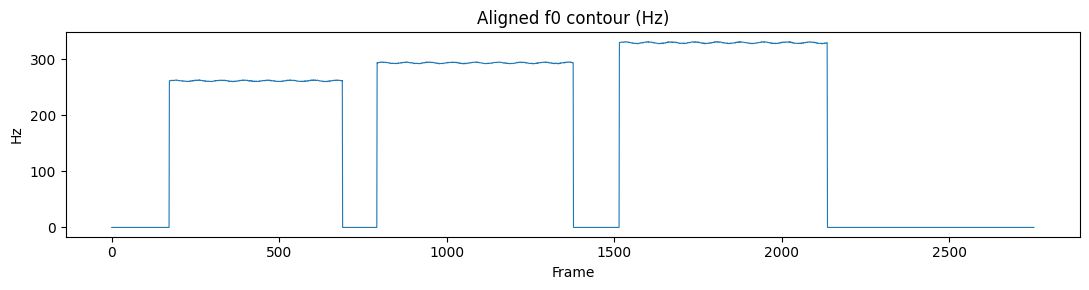

In [4]:
# 1) Helpers: hz_to_cents, voiced_segments, check_and_align_features

cents = hz_to_cents(f0_128)
segments = voiced_segments(f0_128)
print('Detected voiced segments (frame idx):', segments[:5])

f0_aligned, rms_aligned, spec_aligned = check_and_align_features(
    f0_hz=f0_128,
    rms=rms_512,
    spectrum=spectrum_512,
    f0_hop=128,
    rms_hop=512,
    spectrum_hop=512,
    target_hop=128,
    fs=fs,
    verbose=True,
)

print('Aligned shapes:', f0_aligned.shape, rms_aligned.shape, spec_aligned.shape)

plt.figure(figsize=(11, 3))
plt.plot(f0_aligned, lw=0.8)
plt.title('Aligned f0 contour (Hz)')
plt.xlabel('Frame')
plt.ylabel('Hz')
plt.tight_layout()
plt.show()

local_max=0, gauss=48, volume=0, pitch_dip=0
merged onsets=48, note intervals=49


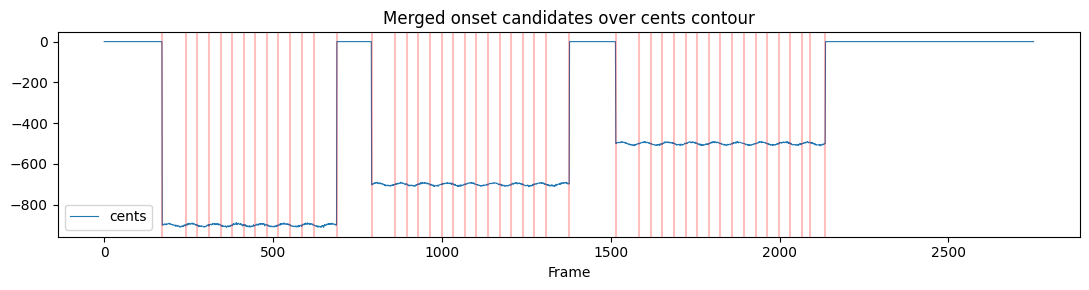

In [5]:
# 2) Segmentation functions overview

cents_aligned = hz_to_cents(f0_aligned)

o1 = detect_onsets_local_maxima(cents_aligned, fs=fs, hop_size=target_hop)
o2 = detect_onsets_gaussian_derivative(cents_aligned, fs=fs, hop_size=target_hop)
o3 = detect_onsets_volume_dip(rms_aligned)
o4 = detect_onsets_pitch_dip(cents_aligned)
onsets = merge_and_deduplicate(o1, o2, o3, o4, min_gap_frames=5)
intervals = segment_contour(
    f0_hz=f0_aligned,
    rms=rms_aligned,
    fs=fs,
    hop_size=target_hop,
)

print(f'local_max={len(o1)}, gauss={len(o2)}, volume={len(o3)}, pitch_dip={len(o4)}')
print(f'merged onsets={len(onsets)}, note intervals={len(intervals)}')

plt.figure(figsize=(11, 3))
plt.plot(cents_aligned, lw=0.8, label='cents')
for x in onsets:
    plt.axvline(x, color='r', alpha=0.25)
plt.title('Merged onset candidates over cents contour')
plt.xlabel('Frame')
plt.legend()
plt.tight_layout()
plt.show()

tuning_cents=0.142
first segment frames=[172, 241) -> predicted MIDI=60


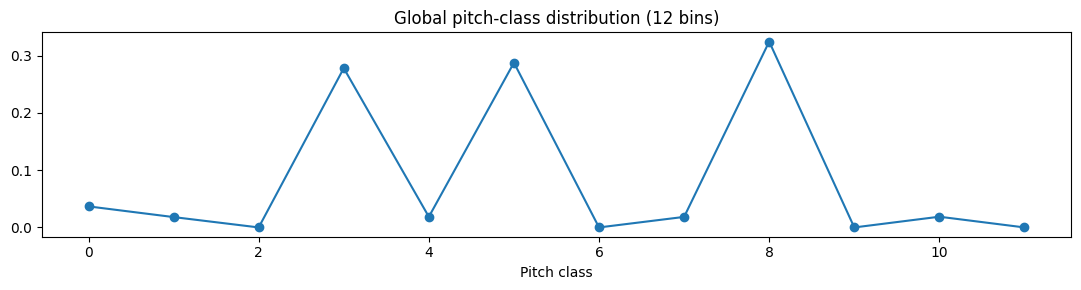

In [6]:
# 3) Pitch-labelling functions overview

tuning_cents = estimate_tuning_deviation(f0_aligned)
L_global = compute_global_pitch_class_probability(
    spectrum=spec_aligned,
    fs=fs,
    hop_size=target_hop,
    tuning_cents=tuning_cents,
)

# Take first segmented note (if any) and inspect local probabilities
if intervals:
    s0, e0 = intervals[0]
    f0_seg = f0_aligned[s0:e0]
    L_local = compute_local_pitch_probability(f0_seg, tuning_cents=tuning_cents)
    midi_label = assign_pitch_label(f0_seg, L_global, tuning_cents=tuning_cents)

    print(f'tuning_cents={tuning_cents:.3f}')
    print(f'first segment frames=[{s0}, {e0}) -> predicted MIDI={midi_label}')

    plt.figure(figsize=(11, 3))
    plt.plot(L_global, marker='o')
    plt.title('Global pitch-class distribution (12 bins)')
    plt.xlabel('Pitch class')
    plt.tight_layout()
    plt.show()
else:
    print('No intervals found in synthetic example.')

Total notes: 46
onset=0.499s, dur=0.200s, midi=60
onset=0.700s, dur=0.099s, midi=60
onset=0.798s, dur=0.102s, midi=60
onset=0.900s, dur=0.102s, midi=60
onset=1.051s, dur=0.148s, midi=60
onset=1.199s, dur=0.102s, midi=60
onset=1.300s, dur=0.099s, midi=60
onset=1.399s, dur=0.099s, midi=60
onset=1.498s, dur=0.102s, midi=60
onset=1.599s, dur=0.102s, midi=60


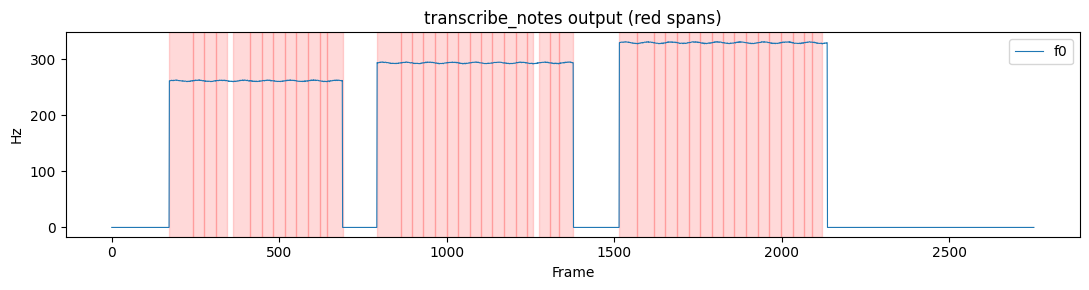

In [7]:
# 4) End-to-end overview: transcribe_notes

notes = transcribe_notes(
    f0_hz=f0_aligned,
    rms=rms_aligned,
    spectrum=spec_aligned,
    fs=fs,
    hop_size=target_hop,
)

print(f'Total notes: {len(notes)}')
for n in notes[:10]:
    print(f'onset={n.onset:.3f}s, dur={n.duration:.3f}s, midi={n.midi}')

# Quick visualization
plt.figure(figsize=(11, 3))
plt.plot(f0_aligned, lw=0.8, label='f0')
for n in notes:
    s = int(n.onset / hop_s)
    e = int((n.onset + n.duration) / hop_s)
    plt.axvspan(s, e, color='red', alpha=0.15)
plt.title('transcribe_notes output (red spans)')
plt.xlabel('Frame')
plt.ylabel('Hz')
plt.legend()
plt.tight_layout()
plt.show()

## Real-data example (no synthetic signals)

This section runs the same workflow on one real track using:

- f0: `f0est/f0Contour_voiceDemucs_PESTO`
- lowlevel: `data/cante2midi_lowlevel`
- spectrum: `data/cante2midi_spectrum`

It mirrors the logic in `noteTranscription/main.py`: load → align → segment helpers → `transcribe_notes`.

In [8]:
from pathlib import Path

# Resolve repo root robustly (works whether cwd is repo root or noteTranscription/)
cwd = Path.cwd()
if (cwd / 'f0est').exists() and (cwd / 'data').exists():
    repo_root = cwd
elif (cwd.parent / 'f0est').exists() and (cwd.parent / 'data').exists():
    repo_root = cwd.parent
else:
    raise RuntimeError(f'Could not infer repo root from cwd={cwd}')

f0_dir = repo_root / 'f0est' / 'f0Contour_voiceDemucs_PESTO'
lowlevel_dir = repo_root / 'data' / 'cante2midi_lowlevel'
spectrum_dir = repo_root / 'data' / 'cante2midi_spectrum'

assert f0_dir.exists(), f'Missing f0 dir: {f0_dir}'
assert lowlevel_dir.exists(), f'Missing lowlevel dir: {lowlevel_dir}'
assert spectrum_dir.exists(), f'Missing spectrum dir: {spectrum_dir}'

# Pick one real track that exists in all 3 folders
f0_files = sorted(f0_dir.glob('*.f0.csv'))
assert f0_files, f'No f0 files in {f0_dir}'

track_id = None
f0_path = None
for p in f0_files:
    tid = p.name.replace('.f0.csv', '')
    ll = lowlevel_dir / f'{tid}.lowlevel.csv'
    sp = spectrum_dir / f'{tid}.spectrum.csv'
    if ll.exists() and sp.exists():
        track_id = tid
        f0_path = p
        lowlevel_path = ll
        spectrum_path = sp
        break

assert track_id is not None, 'No matching real track found across f0/lowlevel/spectrum.'

print('Selected track:', track_id)
print('f0:', f0_path)
print('lowlevel:', lowlevel_path)
print('spectrum:', spectrum_path)

# --- Loaders equivalent to noteTranscription/main.py ---
def load_f0_any(path: Path) -> np.ndarray:
    first_line = path.open('r', encoding='utf-8').readline().strip().lower()
    has_header = any(ch.isalpha() for ch in first_line)

    if has_header:
        data = np.genfromtxt(path, delimiter=',', names=True, dtype=float)
        if 'f0_hz' in (data.dtype.names or ()):
            return np.asarray(data['f0_hz'], dtype=float)
        if data.dtype.names and len(data.dtype.names) >= 2:
            return np.asarray(data[data.dtype.names[1]], dtype=float)
        raise ValueError(f'Could not parse headered f0 CSV: {path}')

    data = np.loadtxt(path, delimiter=',')
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 1].astype(float)


def load_lowlevel_rms(path: Path) -> np.ndarray:
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 6].astype(float)  # RMS column


def load_spectrum_mag(path: Path) -> np.ndarray:
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 1:].astype(float)  # skip time

f0_real = load_f0_any(f0_path)
rms_real = load_lowlevel_rms(lowlevel_path)
spec_real = load_spectrum_mag(spectrum_path)

# Align to target hop (same as main.py defaults)
f0_real, rms_real, spec_real = check_and_align_features(
    f0_hz=f0_real,
    rms=rms_real,
    spectrum=spec_real,
    f0_hop=128,
    rms_hop=512,
    spectrum_hop=512,
    target_hop=128,
    fs=44100,
    verbose=True,
)

print('Aligned shapes:', f0_real.shape, rms_real.shape, spec_real.shape)

Selected track: 01_GabrielMoreno_YoNoTeHeDaoMotivos
f0: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/f0est/f0Contour_voiceDemucs_PESTO/01_GabrielMoreno_YoNoTeHeDaoMotivos.f0.csv
lowlevel: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/data/cante2midi_lowlevel/01_GabrielMoreno_YoNoTeHeDaoMotivos.lowlevel.csv
spectrum: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/data/cante2midi_spectrum/01_GabrielMoreno_YoNoTeHeDaoMotivos.spectrum.csv
Input durations:  f0=248.845s  rms=248.860s  spec=248.860s
After alignment:  all 85735 frames = 248.845s @ hop=128
Aligned shapes: (85735,) (85735,) (85735, 513)


Voiced segments: 211
onset detectors -> local=102, gauss=944, volume=235, pitch_dip=78
Merged onsets: 1280 | Segmented intervals: 983
Estimated tuning deviation: 22.721 cents
Total transcribed notes (real track): 883
First 10 notes:
  onset=16.829s, dur=0.070s, midi=56
  onset=16.898s, dur=0.122s, midi=56
  onset=17.807s, dur=0.084s, midi=56
  onset=17.891s, dur=0.087s, midi=56
  onset=17.850s, dur=0.116s, midi=56
  onset=17.966s, dur=0.078s, midi=56
  onset=18.045s, dur=0.131s, midi=56
  onset=47.296s, dur=0.154s, midi=63
  onset=47.450s, dur=0.180s, midi=63
  onset=47.630s, dur=0.055s, midi=63


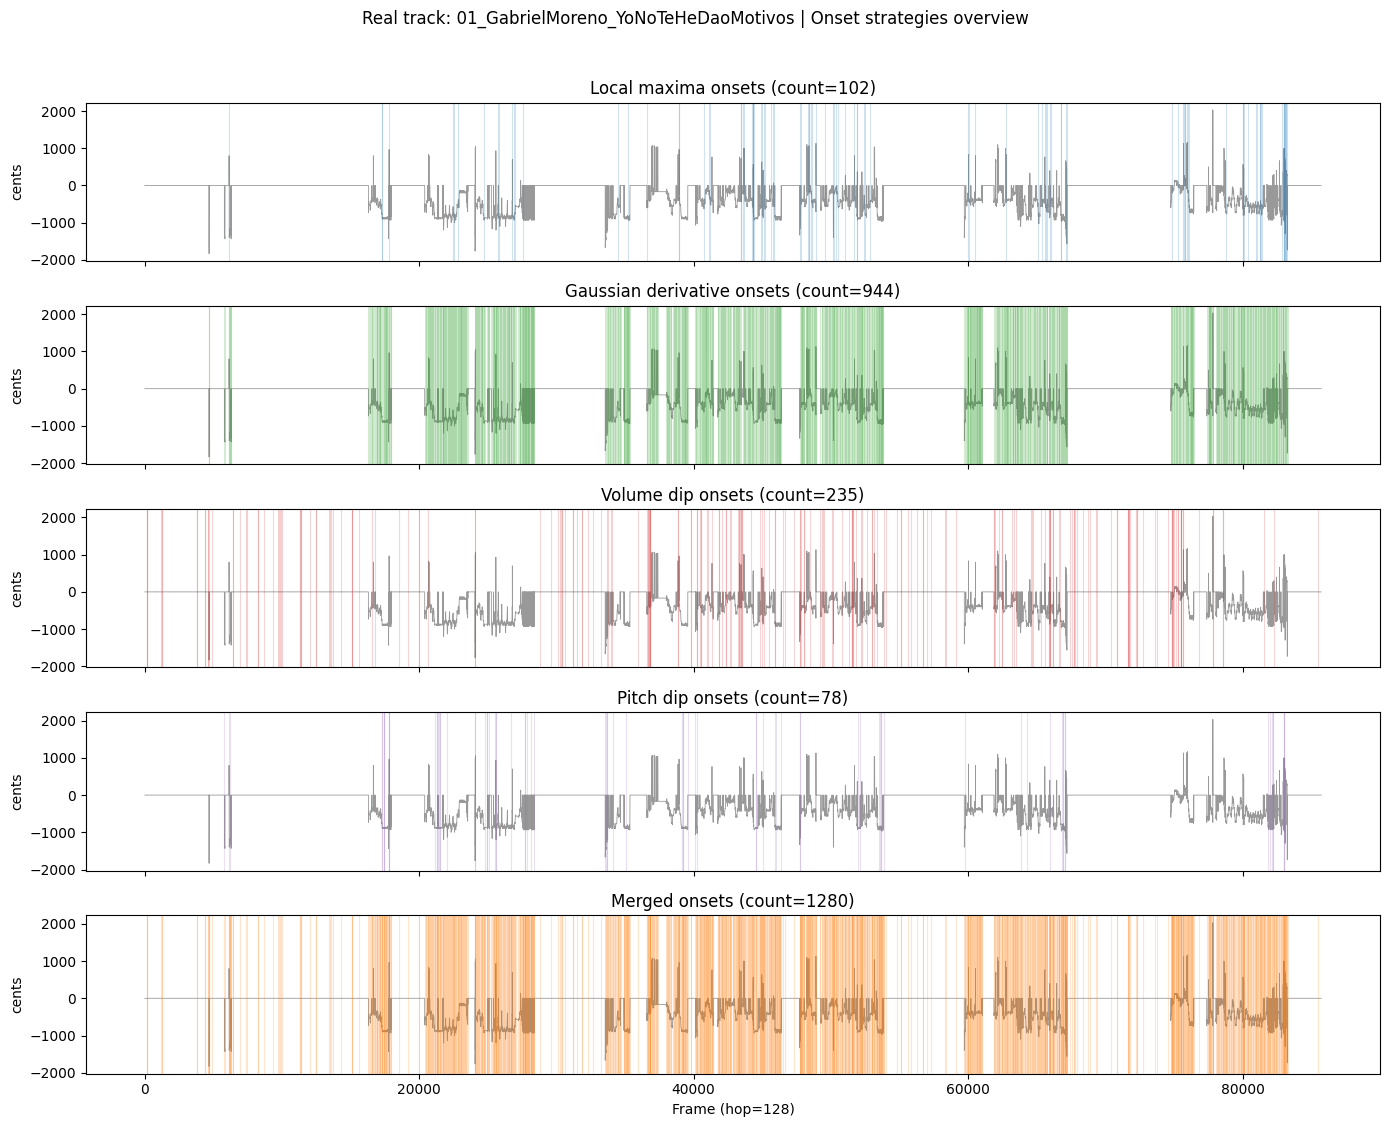

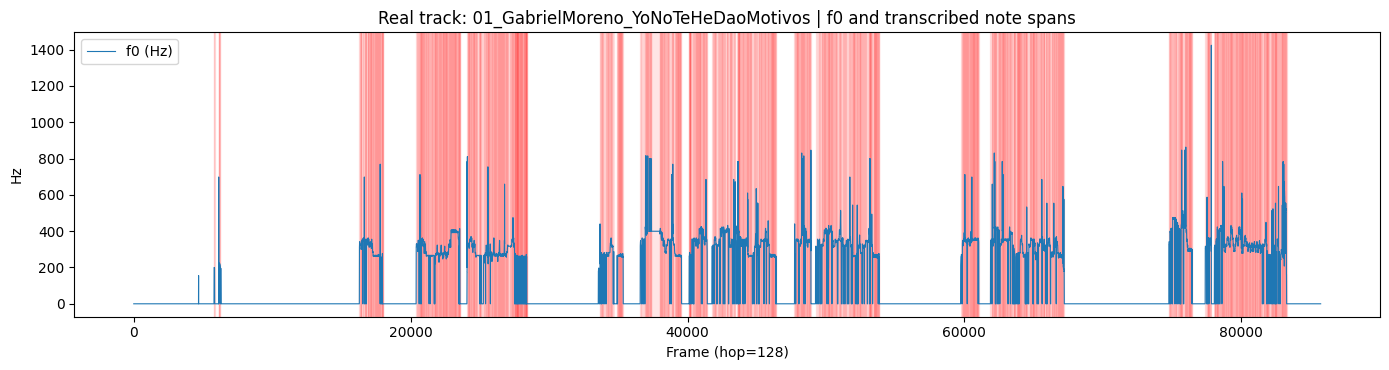

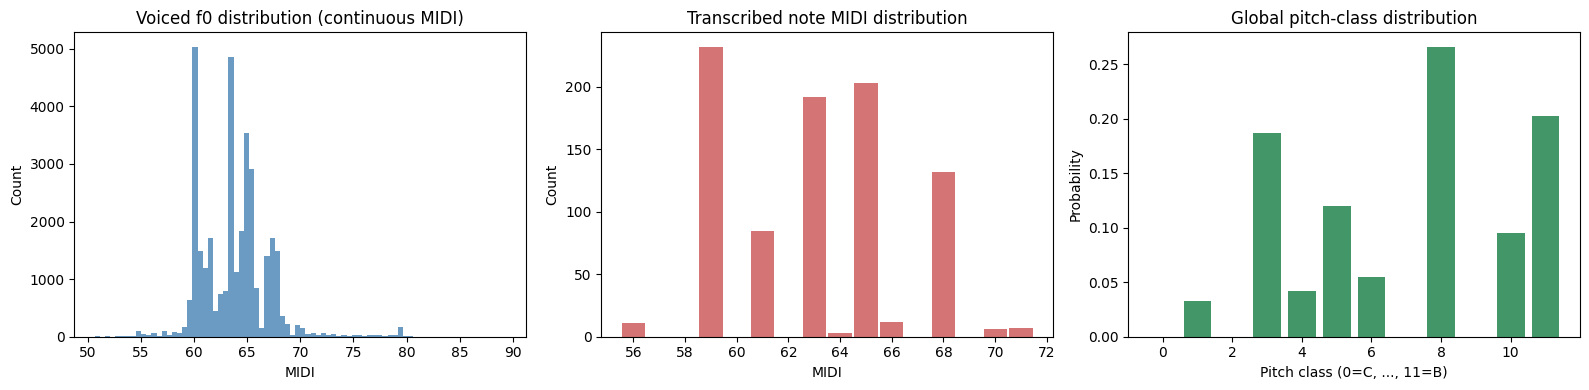

In [9]:
# Run the same function overview on this real track
cents_real = hz_to_cents(f0_real)
segments_real = voiced_segments(f0_real)

o1_real = detect_onsets_local_maxima(cents_real, fs=44100, hop_size=128)
o2_real = detect_onsets_gaussian_derivative(cents_real, fs=44100, hop_size=128)
o3_real = detect_onsets_volume_dip(rms_real)
o4_real = detect_onsets_pitch_dip(cents_real)
onsets_real = merge_and_deduplicate(o1_real, o2_real, o3_real, o4_real, min_gap_frames=5)
intervals_real = segment_contour(f0_real, rms_real, fs=44100, hop_size=128)

print('Voiced segments:', len(segments_real))
print(f'onset detectors -> local={len(o1_real)}, gauss={len(o2_real)}, volume={len(o3_real)}, pitch_dip={len(o4_real)}')
print('Merged onsets:', len(onsets_real), '| Segmented intervals:', len(intervals_real))

# Pitch-model components
tuning_real = estimate_tuning_deviation(f0_real)
L_global_real = compute_global_pitch_class_probability(spec_real, fs=44100, hop_size=128, tuning_cents=tuning_real)
print(f'Estimated tuning deviation: {tuning_real:.3f} cents')

# End-to-end transcription
notes_real = transcribe_notes(
    f0_hz=f0_real,
    rms=rms_real,
    spectrum=spec_real,
    fs=44100,
    hop_size=128,
)
print('Total transcribed notes (real track):', len(notes_real))
print('First 10 notes:')
for n in notes_real[:10]:
    print(f'  onset={n.onset:.3f}s, dur={n.duration:.3f}s, midi={n.midi}')

# ---------------------------------------------------------
# Visualization A: each onset strategy separately + merged
# ---------------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
strategy_data = [
    ('Local maxima onsets', o1_real, 'tab:blue'),
    ('Gaussian derivative onsets', o2_real, 'tab:green'),
    ('Volume dip onsets', o3_real, 'tab:red'),
    ('Pitch dip onsets', o4_real, 'tab:purple'),
    ('Merged onsets', onsets_real, 'tab:orange'),
]

for ax, (title, idxs, color) in zip(axes, strategy_data):
    ax.plot(cents_real, lw=0.6, color='gray', alpha=0.8)
    for x in idxs:
        ax.axvline(x, color=color, alpha=0.20, linewidth=0.8)
    ax.set_title(f'{title} (count={len(idxs)})')
    ax.set_ylabel('cents')

axes[-1].set_xlabel('Frame (hop=128)')
plt.suptitle(f'Real track: {track_id} | Onset strategies overview', y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization B: f0 + transcribed note spans
# ---------------------------------------------------------
plt.figure(figsize=(14, 3.8))
plt.plot(f0_real, lw=0.8, label='f0 (Hz)')
for n in notes_real:
    s = int(n.onset / (128 / 44100))
    e = int((n.onset + n.duration) / (128 / 44100))
    plt.axvspan(s, e, color='red', alpha=0.10)
plt.ylabel('Hz')
plt.xlabel('Frame (hop=128)')
plt.title(f'Real track: {track_id} | f0 and transcribed note spans')
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization C: pitch distributions
# ---------------------------------------------------------
voiced_f0 = f0_real[f0_real > 0]
voiced_midi_cont = 69 + 12 * np.log2(voiced_f0 / 440.0)

note_midis = np.array([n.midi for n in notes_real], dtype=int) if notes_real else np.array([], dtype=int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Continuous voiced f0 distribution in MIDI space
axes[0].hist(voiced_midi_cont, bins=80, color='steelblue', alpha=0.8)
axes[0].set_title('Voiced f0 distribution (continuous MIDI)')
axes[0].set_xlabel('MIDI')
axes[0].set_ylabel('Count')

# Discrete transcribed note MIDI distribution
if len(note_midis) > 0:
    bins = np.arange(note_midis.min(), note_midis.max() + 2) - 0.5
    axes[1].hist(note_midis, bins=bins, color='indianred', alpha=0.85, rwidth=0.9)
axes[1].set_title('Transcribed note MIDI distribution')
axes[1].set_xlabel('MIDI')
axes[1].set_ylabel('Count')

# Global pitch-class distribution from spectrum model
axes[2].bar(np.arange(12), L_global_real, color='seagreen', alpha=0.9)
axes[2].set_title('Global pitch-class distribution')
axes[2].set_xlabel('Pitch class (0=C, ..., 11=B)')
axes[2].set_ylabel('Probability')

plt.tight_layout()
plt.show()